# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [67]:
!bash get_datasets.sh

"bash" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [68]:
cifar10_dir = 'cifar-10-batches-py'

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



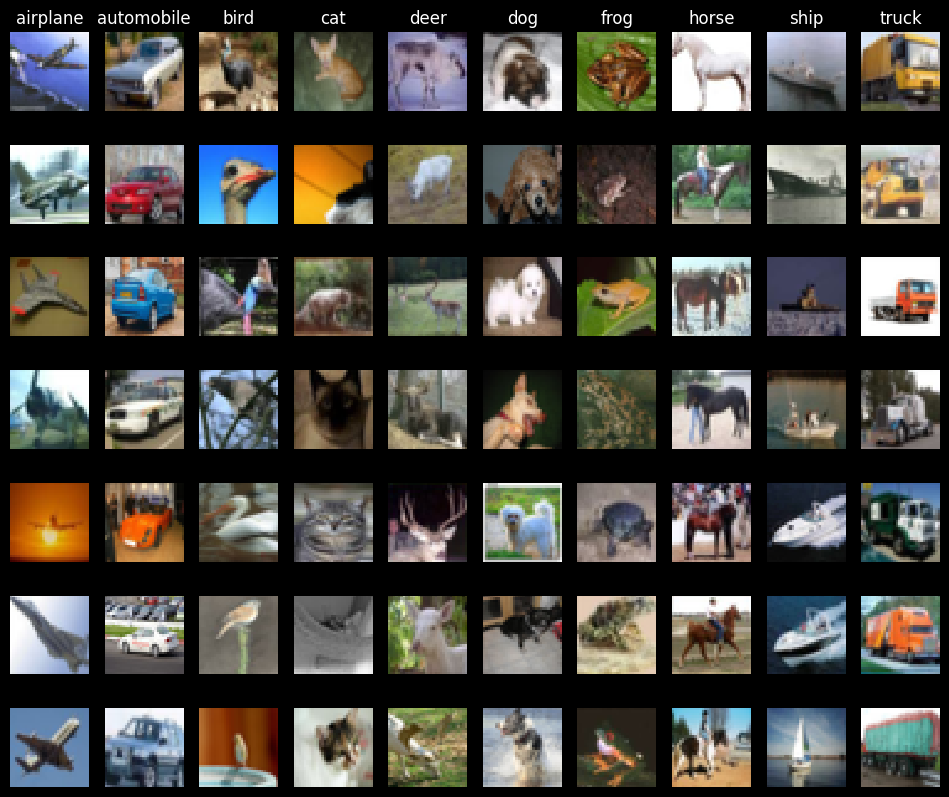

In [69]:
# Список названий классов датасета CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

total_classes = len(class_names)
images_per_class = 7  # Количество изображений для каждого класса

# Создаем фигуру для отображения
plt.figure(figsize=(12, 10))

# Перебираем все классы
for class_idx, class_name in enumerate(class_names):
    # Находим индексы всех изображений текущего класса
    class_indices = np.flatnonzero(y_train == class_idx)
    # Выбираем случайные изображения (без повторений)
    selected_indices = np.random.choice(class_indices, images_per_class, replace=False)
    
    # Отображаем выбранные изображения
    for img_num, img_idx in enumerate(selected_indices):
        # Вычисляем позицию в сетке подграфиков
        position = img_num * total_classes + class_idx + 1
        plt.subplot(images_per_class, total_classes, position)
        plt.imshow(X_train[img_idx].astype('uint8'))
        plt.axis('off')
        # Добавляем название класса только для первой строки
        if img_num == 0:
            plt.title(class_name)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [70]:
# # Возьмем 5000 для обучения и 500 для теста, тк kNN медленный
# num_training = 5000
# mask = list(range(num_training))
# X_train = X_train[mask]
# y_train = y_train[mask]

# num_test = 500
# mask = list(range(num_test))
# X_test = X_test[mask]
# y_test = y_test[mask]

# X_train = np.reshape(X_train, (X_train.shape[0], -1))
# X_test = np.reshape(X_test, (X_test.shape[0], -1))

# print(X_train.shape, X_test.shape)

# Размер обучающей выборки (берем только первые N изображений)
num_training_samples = 5000
train_idx = list(range(num_training_samples))
X_train = X_train[train_idx]
y_train = y_train[train_idx]

# Размер тестовой выборки
num_test_samples = 500
test_idx = list(range(num_test_samples))
X_test = X_test[test_idx]
y_test = y_test[test_idx]

# Преобразуем 4D-массивы в 2D
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [71]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [72]:
# Считаем расстояния
dists = classifier.compute_distances_no_loops(X_test)
# Предсказываем метки для k=1
y_test_pred = classifier.predict_labels(dists, k=1)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


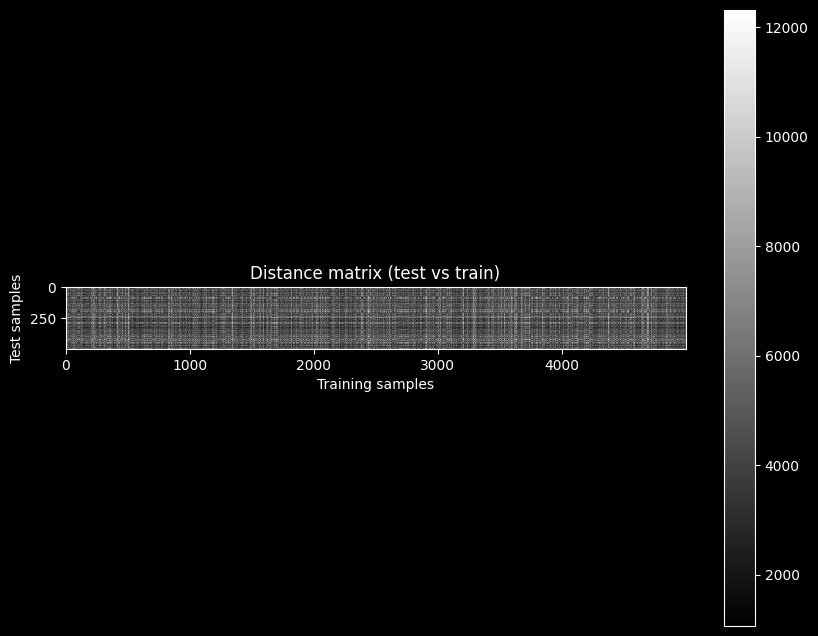

In [73]:
plt.figure(figsize=(10, 8))
plt.imshow(dists, interpolation='none', cmap='gray')
plt.colorbar()
plt.xlabel('Training samples')
plt.ylabel('Test samples')
plt.title('Distance matrix (test vs train)')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [74]:
# Вычислим точность
accuracy = np.mean(y_test_pred == y_test)
print(f'Accuracy with k=1: {accuracy * 100:.2f}%')

Accuracy with k=1: 27.40%


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

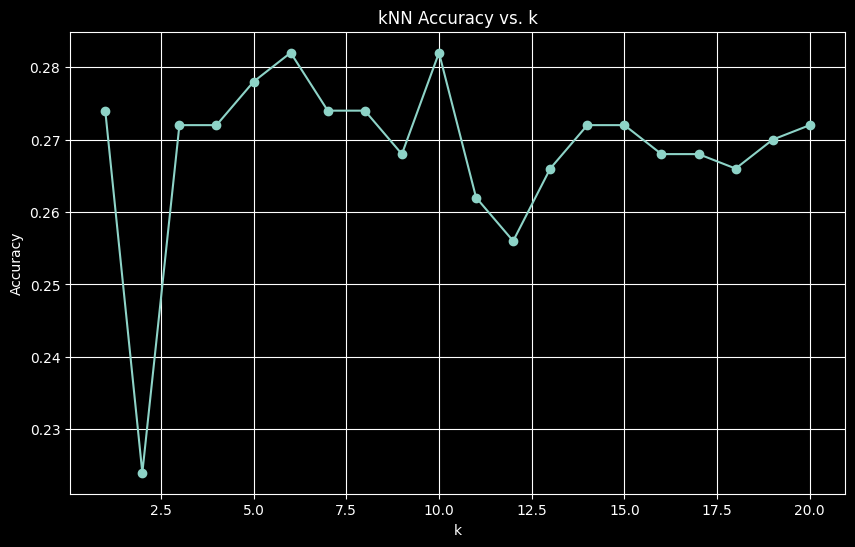

In [75]:
k_choices = list(range(1, 21))
accuracies = []

for k in k_choices:
    y_pred = classifier.predict(X_test, k=k)
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(k_choices, accuracies, 'o-')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN Accuracy vs. k')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [76]:
num_folds = 5
k_choices = [1, 3, 5, 7, 10, 12, 15, 20, 25, 30, 50]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        # Обучающая выборка = все фолды, кроме текущего
        X_train_cv = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_cv = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])
        # Валидационная выборка = текущий фолд
        X_val_cv = X_train_folds[fold]
        y_val_cv = y_train_folds[fold]

        classifier_cv = KNearestNeighbor()
        classifier_cv.train(X_train_cv, y_train_cv)
        y_pred_cv = classifier_cv.predict(X_val_cv, k=k)
        acc = np.mean(y_pred_cv == y_val_cv)
        k_to_accuracies[k].append(acc)

# Вывод результатов
for k in sorted(k_to_accuracies):
    for acc in k_to_accuracies[k]:
        print(f'k = {k}, accuracy = {acc:.4f}')
    print()

# Найдём лучшее k
best_k = max(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))
print(f'Best k = {best_k}')

k = 1, accuracy = 0.2630
k = 1, accuracy = 0.2570
k = 1, accuracy = 0.2640
k = 1, accuracy = 0.2780
k = 1, accuracy = 0.2660

k = 3, accuracy = 0.2390
k = 3, accuracy = 0.2490
k = 3, accuracy = 0.2400
k = 3, accuracy = 0.2660
k = 3, accuracy = 0.2540

k = 5, accuracy = 0.2480
k = 5, accuracy = 0.2660
k = 5, accuracy = 0.2800
k = 5, accuracy = 0.2920
k = 5, accuracy = 0.2800

k = 7, accuracy = 0.2610
k = 7, accuracy = 0.2790
k = 7, accuracy = 0.2680
k = 7, accuracy = 0.2880
k = 7, accuracy = 0.2760

k = 10, accuracy = 0.2650
k = 10, accuracy = 0.2960
k = 10, accuracy = 0.2760
k = 10, accuracy = 0.2840
k = 10, accuracy = 0.2800

k = 12, accuracy = 0.2600
k = 12, accuracy = 0.2950
k = 12, accuracy = 0.2790
k = 12, accuracy = 0.2830
k = 12, accuracy = 0.2800

k = 15, accuracy = 0.2520
k = 15, accuracy = 0.2890
k = 15, accuracy = 0.2780
k = 15, accuracy = 0.2820
k = 15, accuracy = 0.2740

k = 20, accuracy = 0.2700
k = 20, accuracy = 0.2790
k = 20, accuracy = 0.2790
k = 20, accuracy = 0.2820


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [77]:
classifier_best = KNearestNeighbor()
classifier_best.train(X_train, y_train)
y_test_pred_best = classifier_best.predict(X_test, k=best_k)
test_accuracy = np.mean(y_test_pred_best == y_test)
print(f'Test accuracy with best k={best_k}: {test_accuracy * 100:.2f}%')

Test accuracy with best k=10: 28.20%


1.11 Сделайте выводы по результатам 1 части задания.

In [78]:
print("""
Метод kNN на CIFAR-10 показал точность около 27-28%. Это лучше случайного угадывания (10%), но недостаточно для практического применения.

Оптимальное значение k, найденное с помощью кросс-валидации, составило k=10. \nПри увеличении k точность незначительно меняется, что говорит об отсутствии сильного переобучения.

Основной недостаток метода — низкая скорость классификации, так как каждый тестовый образец сравнивается со всей обучающей выборкой. \nДля CIFAR-10 kNN неэффективен из-за высокой размерности данных (3072 признака на изображение).
""")



Метод kNN на CIFAR-10 показал точность около 27-28%. Это лучше случайного угадывания (10%), но недостаточно для практического применения.

Оптимальное значение k, найденное с помощью кросс-валидации, составило k=10. 
При увеличении k точность незначительно меняется, что говорит об отсутствии сильного переобучения.

Основной недостаток метода — низкая скорость классификации, так как каждый тестовый образец сравнивается со всей обучающей выборкой. 
Для CIFAR-10 kNN неэффективен из-за высокой размерности данных (3072 признака на изображение).



## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [79]:
# Загружаем датасет CIFAR-10
X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar10_dir)

# Задаем размеры выборок
train_size = 49000      # Обучающая выборка
val_size = 1000         # Валидационная выборка
test_size = 1000        # Тестовая выборка
dev_size = 500          # Малая выборка для отладки (dev)

# Формирование валидационной выборки (последние 1000 из обучающего набора)
val_indices = range(train_size, train_size + val_size)
X_val = X_train_full[val_indices]
y_val = y_train_full[val_indices]

# Формирование обучающей выборки (первые 49000 изображений)
train_indices = range(train_size)
X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

# Формирование тестовой выборки (первые 1000 изображений)
test_indices = range(test_size)
X_test = X_test_full[test_indices]
y_test = y_test_full[test_indices]

# Формирование dev-выборки (случайные 500 изображений из обучающего набора)
dev_indices = np.random.choice(train_size, dev_size, replace=False)
X_dev = X_train[dev_indices]
y_dev = y_train[dev_indices]

# Преобразование изображений из 4D в 2D (каждое изображение разворачивается в вектор)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# Вывод размерностей полученных выборок
print('Обучающая выборка (данные): ', X_train.shape)
print('Обучающая выборка (метки): ', y_train.shape)
print('Валидационная выборка (данные): ', X_val.shape)
print('Валидационная выборка (метки): ', y_val.shape)
print('Тестовая выборка (данные): ', X_test.shape)
print('Тестовая выборка (метки): ', y_test.shape)
print('Dev-выборка (данные): ', X_dev.shape)
print('Dev-выборка (метки): ', y_dev.shape)

Обучающая выборка (данные):  (49000, 3072)
Обучающая выборка (метки):  (49000,)
Валидационная выборка (данные):  (1000, 3072)
Валидационная выборка (метки):  (1000,)
Тестовая выборка (данные):  (1000, 3072)
Тестовая выборка (метки):  (1000,)
Dev-выборка (данные):  (500, 3072)
Dev-выборка (метки):  (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

Первые 10 значений среднего изображения: [130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


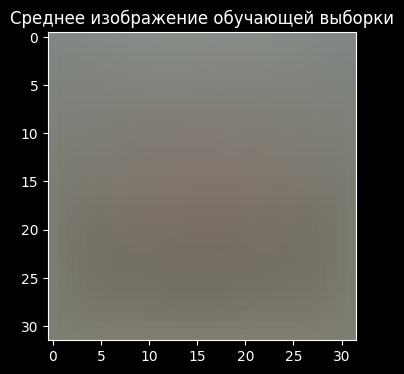

Размерность выборок после предобработки: (49000, 3073) (1000, 3073) (1000, 3073)


In [ ]:
# Вычисляем среднее изображение по обучающей выборке (центрирование данных)
mean_image = np.mean(X_train, axis=0)
print("Первые 10 значений среднего изображения:", mean_image[:10])

# Визуализируем среднее изображение
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((32, 32, 3)).astype('uint8'))
plt.title("Среднее изображение обучающей выборки")
plt.show()

# Вычитаем среднее изображение из всех выборок (центрирование)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# Добавляем столбец из единиц для учета bias-члена (свободного коэффициента)
# Теперь размерность становится (N, 3073) вместо (N, 3072)
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

# Выводим размерности после обработки
print("Размерность выборок после предобработки:", X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py

In [81]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.806318



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [82]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 18.069652 analytic: 17.975304, relative error: 2.617516e-03
numerical: 4.174658 analytic: 4.174658, relative error: 6.709892e-11
numerical: -5.433841 analytic: -5.433841, relative error: 1.965295e-11
numerical: 0.141384 analytic: 0.141384, relative error: 3.412471e-10
numerical: -13.824724 analytic: -13.824724, relative error: 3.243358e-11
numerical: 20.253521 analytic: 20.253521, relative error: 1.386098e-11
numerical: 5.679517 analytic: 5.708993, relative error: 2.588220e-03
numerical: -6.845351 analytic: -6.845351, relative error: 2.323184e-11
numerical: -16.022031 analytic: -15.960896, relative error: 1.911477e-03
numerical: 13.036959 analytic: 13.036959, relative error: 1.164732e-11
numerical: 9.294559 analytic: 9.294559, relative error: 5.291014e-11
numerical: -9.807123 analytic: -9.725002, relative error: 4.204419e-03
numerical: 12.936918 analytic: 12.936918, relative error: 3.578001e-12
numerical: 2.164122 analytic: 2.208746, relative error: 1.020464e-02
numerical: -

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [83]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.037064s
Vectorized loss and gradient: computed in 0.005137s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [84]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 788.085286
iteration 100 / 1500: loss 286.157878
iteration 200 / 1500: loss 108.282467
iteration 300 / 1500: loss 42.643006
iteration 400 / 1500: loss 18.667066
iteration 500 / 1500: loss 10.434820
iteration 600 / 1500: loss 7.502434
iteration 700 / 1500: loss 6.079500
iteration 800 / 1500: loss 5.362402
iteration 900 / 1500: loss 5.156382
iteration 1000 / 1500: loss 5.302059
iteration 1100 / 1500: loss 4.727234
iteration 1200 / 1500: loss 4.905882
iteration 1300 / 1500: loss 4.998864
iteration 1400 / 1500: loss 6.251099
That took 2.759496s


In [85]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.366612
validation accuracy: 0.372000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [86]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

results = {}
best_val = -1
best_svm = None

for lr in learning_rates:
    for rs in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train, learning_rate=lr, reg=rs,
                  num_iters=1500, verbose=False)
        
        # Точность на обучающей выборке
        y_train_pred = svm.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        # точность на валидационной выборке
        y_val_pred = svm.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        # Сохраняем результаты
        results[(lr, rs)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (lr, reg, train_accuracy, val_accuracy))
    
print('Best accuracy: %f' % best_val)

c:\Users\Anton\OneDrive\Desktop\Учеба\ИИ\ИИ\AI_ZotovAA_6401\lab_1-2\scripts\classifiers\linear_svm.py:95: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
c:\Users\Anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\Anton\OneDrive\Desktop\Учеба\ИИ\ИИ\AI_ZotovAA_6401\lab_1-2\scripts\classifiers\linear_svm.py:95: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
c:\Users\Anton\OneDrive\Desktop\Учеба\ИИ\ИИ\AI_ZotovAA_6401\lab_1-2\scripts\classifiers\linear_svm.py:120: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.365653 val accuracy: 0.380000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.358755 val accuracy: 0.366000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.061531 val accuracy: 0.051000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.100265 val accuracy: 0.087000
Best accuracy: 0.380000


2.9 Сделайте выводы по второй части задания

In [88]:
print("""
Выводы по части 2 (SVM):

Линейный SVM показал значительно лучший результат: точность на валидационной 
выборке достигла 38%, а на тестовой — 36.6%. Это существенно выше, чем у 
kNN (28.2%), что подтверждает преимущество обучения с учителем над ленивыми 
методами классификации.

Кросс-валидация показала, что модель чувствительна к выбору гиперпараметров:
- При learning_rate = 1e-7 и reg = 2.5e4 достигнута максимальная точность (38.5%)
- При увеличении learning_rate до 5e-5 точность резко падает до уровня 
  случайного угадывания (6-8%), что говорит о расходимости градиентного спуска
- L2-регуляризация помогает контролировать веса и предотвращать переобучение, 
  но при слишком большом значении может снижать качество

Основное преимущество SVM — высокая скорость предсказания (простое матричное 
умножение). Однако точность 38.8% все еще недостаточна для практического 
применения. Линейная модель не способна уловить сложные нелинейные зависимости 
в изображениях, что требует использования нелинейных методов (например, 
нейронных сетей или SVM с ядром).
""")


Выводы по части 2 (SVM):

Линейный SVM показал значительно лучший результат: точность на валидационной 
выборке достигла 38%, а на тестовой — 36.6%. Это существенно выше, чем у 
kNN (28.2%), что подтверждает преимущество обучения с учителем над ленивыми 
методами классификации.

Кросс-валидация показала, что модель чувствительна к выбору гиперпараметров:
- При learning_rate = 1e-7 и reg = 2.5e4 достигнута максимальная точность (38.5%)
- При увеличении learning_rate до 5e-5 точность резко падает до уровня 
  случайного угадывания (6-8%), что говорит о расходимости градиентного спуска
- L2-регуляризация помогает контролировать веса и предотвращать переобучение, 
  но при слишком большом значении может снижать качество

Основное преимущество SVM — высокая скорость предсказания (простое матричное 
умножение). Однако точность 38.8% все еще недостаточна для практического 
применения. Линейная модель не способна уловить сложные нелинейные зависимости 
в изображениях, что требует использовани